# Evaluation and Deployment

CRISP-DM Evaluation and Deployment summary for the review-concern project.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents) if (path / "pipeline").exists()
)
sys.path.insert(0, str(PROJECT_ROOT))

from pipeline.evaluation import evaluate_project

REPORT_DIR = PROJECT_ROOT / "reports/evaluation_v0.2"
FIGURE_DIR = PROJECT_ROOT / "figures/evaluation"
RUN_EVALUATION = False

if RUN_EVALUATION:
    evaluate_project(
        prep_summary_path=PROJECT_ROOT / "data/processed/modeling_v0.2/dataset_modeling_v0.2.preparation_summary.json",
        modeling_summary_path=PROJECT_ROOT / "reports/modeling_v0.2/modeling_summary.json",
        output_dir=REPORT_DIR,
        figure_dir=FIGURE_DIR,
    )

## Evaluate Results

The scorecard checks whether the data mining results satisfy the original
business and data mining success criteria.

In [2]:
scorecard = pd.read_csv(REPORT_DIR / "evaluation_scorecard.csv")
scorecard

,criterion,target,measured,status,interpretation
0,"At least 5,000 curated workflows",">= 5,000 accepted rows","7,373",pass,The dataset is large enough for the project ob...
1,Broad multi-repository coverage,multi-repository dataset,"6,033 repositories",pass,The collection is not limited to one project o...
2,Downstream model beats random ranking,ROC-AUC > 0.500,0.628,pass,The data contains learnable signal for review-...
3,Downstream model beats majority baseline,macro-F1 > 0.490,0.537,pass,The selected model improves over predicting on...
4,Demonstrable deployment artifact,usable dataset and demo application,Hugging Face dataset and runnable Streamlit demo,pass,"The result can be inspected and demonstrated, ..."


## Review Process

The process review focuses on whether the CRISP-DM steps were sufficient and
whether any weak assumptions remain.

In [3]:
summary = json.loads((REPORT_DIR / "evaluation_summary.json").read_text())
summary["business_result"], summary["data_mining_result"], summary["deployment_result"]

('partially_successful',
 'successful_for_baseline_validation',
 'demonstration_ready')

## Determine Next Steps

The current result is demonstrable, but the model should not be treated as an
operational decision system without another iteration.

In [4]:
summary["recommendation"]

'Use the dataset and app as demonstrators, and continue with another CRISP-DM iteration to improve model quality.'

## Deployment

The deployment artifacts are a public dataset page and a local Streamlit demo.

In [5]:
summary["huggingface_dataset_url"], summary["streamlit_demo_url"]

('https://huggingface.co/datasets/bulatSharif/gh-pr-issue-traces-10k',
 'http://localhost:8501')

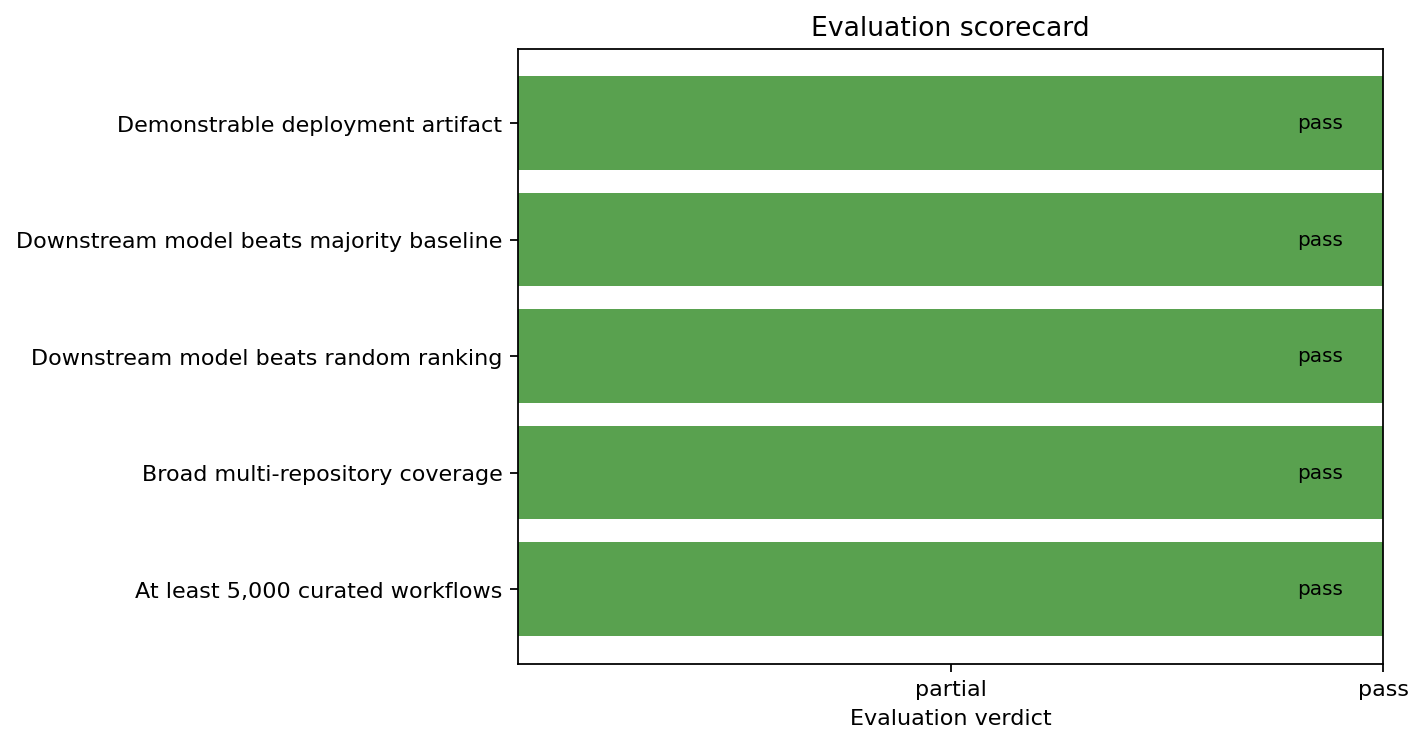

In [6]:
display(Image(filename=str(FIGURE_DIR / "evaluation_scorecard.png")))